# Practice — Debugging

Step through a simple CNN training code **one line at a time**, then fix the models that raise errors.

- Environment: **VS Code** — breakpoints and Debug Cell are required

---
# 1. Setup

- Data: 60000 MNIST training images — the only transform converts them to tensors
- One batch: images `(64, 1, 28, 28)`, labels `(64,)`
- `train` : for every batch, forward → loss → `backward()` → `step()`

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_set = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transforms.ToTensor())
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)

In [2]:
def train(model, train_loader, optimizer, epochs, device):
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            output = model(X_batch)               # logits, (batch, 10)
            loss = criterion(output, Y_batch)

            optimizer.zero_grad()                 # clear the accumulated gradients
            loss.backward()                       # autograd computes the gradients
            optimizer.step()                      # the optimizer updates the parameters

---
# 2. A Simple CNN

Two conv layers + one linear layer. The same model is written in two ways.

| Item | Method 1 — `nn.Sequential` | Method 2 — one operation per line |
|------|----------------------------|-----------------------------------|
| Code | short | long |
| Intermediate results in the debugger | `forward` is a single line → cannot stop between layers | stop at every line and look at `out` |

- Both cells define `SimpleCNN` → the cell **executed last** is the one in use
- To use only one of them, convert the other cell to Markdown

In [3]:
# Method 1 - list the layers in order with nn.Sequential
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(6, 6, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(6 * 7 * 7, 10),
        )

    def forward(self, x):
        out = self.net(x)             # logits - every layer runs in this one line
        return out

In [4]:
# Method 2 - create the layers one by one and call one operation per line in forward
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(6, 6, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(6 * 7 * 7, 10)

    def forward(self, x):
        out = self.conv1(x)
        out = self.relu(out)
        out = self.pool(out)

        out = self.conv2(out)
        out = self.relu(out)
        out = self.pool(out)

        out = out.flatten(1)
        out = self.fc(out)            # logits
        return out

In [5]:
torch.manual_seed(42)
model = SimpleCNN().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

train(model, train_loader, optimizer, epochs=1, device=device)

---
# 3. Using the Debugger

| Goal | How |
|------|-----|
| Choose where to stop (breakpoint) | Click to the left of the line number → red dot |
| Start debugging | Small arrow next to the run button → **Debug Cell** |
| Go to the next line | `F10` (Step Over) |
| Go **into** the function this line calls | `F11` (Step Into) |
| Finish this function and return to **the caller** | `Shift+F11` (Step Out) |
| Run to the next breakpoint | `F5` (Continue) |
| Look at values | Expand a tensor in the VARIABLES pane to see `shape`. An expression such as `out.shape` added to the WATCH pane is evaluated again at every stop |
| Run the selected code right away | Drag to select code → right-click → **Evaluate in Debug Console** (no default shortcut → assign one below) |

- The line highlighted in yellow has **not been executed yet**

### Assigning a shortcut — Evaluate in Debug Console

1. `Ctrl+Shift+P` → type `shortcut` → choose **Preferences: Open Keyboard Shortcuts**
2. Type `Evaluate in Debug Console` in the search box
3. Double-click the entry → press the key you want (e.g. `F9`), then `Enter`

- `F9` is originally the key that sets a breakpoint → after reassigning it, set breakpoints by clicking to the left of the line number

---
# 4. Error — Input Size of `fc`

- Same model as `SimpleCNN`, except that the input size of `fc` is written differently → running it raises an error
- Find the cause with the debugger and fix it (hints are in the code comments)
- After fixing the model cell, rerun it and the training cell below → success if it finishes without an error

In [6]:
class FcErrorCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(6, 6, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(6 * 14 * 14, 10)    # wrong input size

    def forward(self, x):
        out = self.conv1(x)
        out = self.relu(out)
        out = self.pool(out)

        out = self.conv2(out)
        out = self.relu(out)
        out = self.pool(out)

        out = out.flatten(1)
        out = self.fc(out)            # logits (the line that raises the error)
        # Why it fails : the input size fc expects (6 * 14 * 14) differs from the size of out after flatten.
        # How to fix   : set a breakpoint on this line, check out.shape, and change the input size of fc to 6 * 7 * 7.
        return out

In [7]:
torch.manual_seed(42)
model = FcErrorCNN().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

train(model, train_loader, optimizer, epochs=1, device=device)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x294 and 1176x10)

---
# 5. Error — Residual Connection

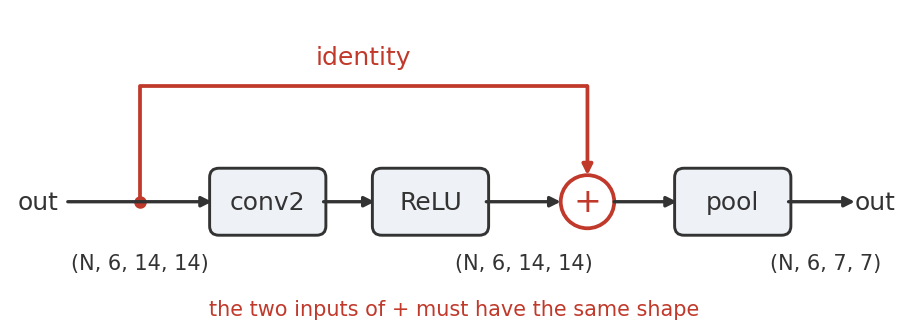

- `identity` : keep the value from before the block, then add it to the output of the block
- The figure shows the **correct structure**. In the code below the addition sits in a different place, so it raises an error (hints are in the code comments)

In [8]:
class ResidualCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(6, 6, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(6 * 7 * 7, 10)

    def forward(self, x):
        out = self.conv1(x)
        out = self.relu(out)
        out = self.pool(out)

        identity = out                # keep the value to add later
        out = self.conv2(out)
        out = self.relu(out)
        out = self.pool(out)
        out = out + identity          # residual connection (the line that raises the error)
        # Why it fails : out and identity differ in height and width. They were added after pool halved the size.
        # How to fix   : move the addition before pool (conv2 -> relu -> + identity -> pool).

        out = out.flatten(1)
        out = self.fc(out)            # logits
        return out

In [9]:
torch.manual_seed(42)
model = ResidualCNN().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

train(model, train_loader, optimizer, epochs=1, device=device)

RuntimeError: The size of tensor a (7) must match the size of tensor b (14) at non-singleton dimension 3

---
# 6. When `train` Lives in a Separate `.py` File

- `train_py.py` : contains the same function as `train` in Section 1 (same folder as this notebook)
- Open `train_py.py`, set a breakpoint, and run the training cell below with Debug Cell → execution stops **inside the `.py` file** as well
- After editing the `.py` file, restart the kernel for the change to take effect
- To go back to the `train` defined in the notebook, rerun the `train` cell in Section 1

In [10]:
from train_py import train    # train is now the function in train_py.py

In [11]:
torch.manual_seed(42)
model = SimpleCNN().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

train(model, train_loader, optimizer, epochs=1, device=device)